# CO₂ Ground State Estimation in the NISQ Era

Hybrid quantum-classical workflow for estimating the ground-state energy of **carbon dioxide (CO₂)** using:

1. **VQE** — Variational Quantum Eigensolver with multiple ansätze and optimizers  
2. **SQD** — Sample-based Quantum Diagonalization (after Robledo-Moreno et al., *Nature* 2024)  
3. **Classical references** — Hartree-Fock and exact diagonalization (FCI) in the active space

**Framework:** Qiskit Nature 0.7 + PySCF  
**Active space:** 4 electrons, 4 orbitals → 8 spin-orbitals → **6 qubits** (ParityMapper + 2-qubit reduction)

## 0. Environment Setup

> ⚠️ **Run this cell first, then restart the kernel before continuing.**
>
> `qiskit-algorithms 0.4+` requires Qiskit ≥ 1.x, but `qiskit-nature 0.7` requires Qiskit 0.x — they are mutually exclusive.  
> The pinned stack below is the last set of versions that works together on Python 3.9–3.11.  
> If you are on **Python 3.12** (default in newer Colab), switch the runtime to Python 3.10 or 3.11 first.

In [ ]:
# ── Pinned compatible stack ────────────────────────────────────────────────
# qiskit 0.46.x  = last 0.x release (includes terra 0.46)
# qiskit-aer 0.13.x = last Aer that targets 0.x terra
# qiskit-algorithms 0.3.x  = last version that targets 0.x primitives
#                            (0.4.0 requires qiskit>=1.0 → conflict with nature)
# qiskit-nature 0.7.x = last nature release, requires qiskit<1.0
# --------------------------------------------------------------------------
import sys
print(f"Python {sys.version}")

%pip install -q \
    "qiskit==0.46.2" \
    "qiskit-aer==0.13.3" \
    "qiskit-algorithms==0.3.1" \
    "qiskit-nature==0.7.2" \
    "pyscf>=2.3" \
    "scipy>=1.10" \
    "matplotlib>=3.7"

print("\n✅ Installation complete — RESTART THE KERNEL NOW, then run from Cell 1.")

Python 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.5/310.5 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.3/50.3 MB 13.4 MB/s eta 0:00:00

✅ Installation complete — RESTART THE KERNEL NOW, then run from Cell 1.


## 1. Imports & Dependencies

In [ ]:
from __future__ import annotations

import json
import time
from dataclasses import dataclass, field, asdict
from pathlib import Path

import numpy as np
import scipy.sparse.linalg as spla

# ── Qiskit core (0.46 API) ────────────────────────────────────────────────
from qiskit.circuit.library import EfficientSU2
from qiskit.quantum_info import SparsePauliOp

# qiskit 0.46 primitives: Estimator / Sampler live here as reference impls
from qiskit.primitives import Estimator as RefEstimator
from qiskit.primitives import Sampler   as RefSampler

# ── Qiskit Aer noise model ────────────────────────────────────────────────
from qiskit_aer.primitives import Estimator as AerEstimator
from qiskit_aer.noise import NoiseModel, depolarizing_error

# ── Algorithms (0.3.x API — compatible with 0.46 primitives) ─────────────
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA, SPSA, L_BFGS_B

# ── Qiskit Nature 0.7 ─────────────────────────────────────────────────────
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import ParityMapper, JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock

# ── Plotting ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

# ── Version sanity check ──────────────────────────────────────────────────
import qiskit, qiskit_algorithms, qiskit_nature
print(f"qiskit            {qiskit.__version__}")
print(f"qiskit-algorithms {qiskit_algorithms.__version__}")
print(f"qiskit-nature     {qiskit_nature.__version__}")
print("\n✅ All imports OK.")

qiskit            0.46.2
qiskit-algorithms 0.3.1
qiskit-nature     0.7.2

✅ All imports OK.


## 2. Configuration

In [ ]:
# Experimental CO2 geometry (linear, C-O = 1.16 Å)
CO2_GEOMETRY = "O 0.0 0.0 -1.16; C 0.0 0.0 0.0; O 0.0 0.0 1.16"
BASIS = "sto3g"

# Active space: 4 electrons in 4 frontier orbitals.
# CO2 has 22 electrons / 15 spatial orbitals at STO-3G.
# We freeze core/sigma backbone and keep the π system: 4e in 4 orbitals.
ACTIVE_ELECTRONS = 4
ACTIVE_ORBITALS  = 4   # → 8 spin-orbitals → 6 qubits (ParityMapper + 2-qubit reduction)

CHEM_ACC = 1.6e-3      # 1 kcal/mol ≈ 1.594 mHa  (conventional chemical accuracy)

OUT_DIR = Path("results")
OUT_DIR.mkdir(exist_ok=True)
print(f"Output directory: {OUT_DIR.resolve()}")

Output directory: /content/results


## 3. Result Containers

In [ ]:
@dataclass
class VQEResult:
    label: str
    ansatz: str
    optimizer: str
    final_energy: float
    error_vs_fci: float
    n_iters: int
    n_evals: int
    wall_time_s: float
    convergence: list[float] = field(default_factory=list)
    n_qubits: int = 0
    n_parameters: int = 0
    noisy: bool = False
    optimal_params: list[float] = field(default_factory=list)


@dataclass
class SQDResult:
    label: str
    shots: int
    subspace_dim: int
    energy: float
    error_vs_fci: float
    wall_time_s: float

print("Dataclasses defined.")

Dataclasses defined.


## 4. Problem Construction

In [ ]:
def build_problem():
    """Run PySCF (HF) and build the full electronic-structure problem."""
    driver = PySCFDriver(
        atom=CO2_GEOMETRY,
        basis=BASIS,
        charge=0,
        spin=0,
        unit=DistanceUnit.ANGSTROM,
    )
    full_problem = driver.run()
    transformer  = ActiveSpaceTransformer(
        num_electrons=ACTIVE_ELECTRONS,
        num_spatial_orbitals=ACTIVE_ORBITALS,
    )
    as_problem = transformer.transform(full_problem)
    return full_problem, as_problem


def map_to_qubits(problem, reduce_qubits: bool = True):
    """Map the second-quantized Hamiltonian to Pauli operators."""
    mapper = (
        ParityMapper(num_particles=problem.num_particles)
        if reduce_qubits else JordanWignerMapper()
    )
    hamiltonian = problem.hamiltonian.second_q_op()
    qubit_op: SparsePauliOp = mapper.map(hamiltonian)
    return qubit_op, mapper

print("Problem-construction helpers defined.")

Problem-construction helpers defined.


## 5. Classical References (HF & FCI)

In [ ]:
def exact_diagonalization(qubit_op: SparsePauliOp) -> float:
    """Lowest eigenvalue via exact (sparse) diagonalization."""
    mat = qubit_op.to_matrix(sparse=True)
    if mat.shape[0] <= 64:
        return float(np.linalg.eigvalsh(qubit_op.to_matrix()).min())
    eigvals = spla.eigsh(mat, k=1, which="SA", return_eigenvectors=False)
    return float(eigvals[0])

print("Exact diagonalization helper defined.")

Exact diagonalization helper defined.


## 6. Ansatz Factories

In [ ]:
def make_uccsd(problem, mapper):
    """Chemistry-inspired UCCSD ansatz seeded from the Hartree-Fock reference."""
    hf_state = HartreeFock(
        num_spatial_orbitals=problem.num_spatial_orbitals,
        num_particles=problem.num_particles,
        qubit_mapper=mapper,
    )
    return UCCSD(
        num_spatial_orbitals=problem.num_spatial_orbitals,
        num_particles=problem.num_particles,
        qubit_mapper=mapper,
        initial_state=hf_state,
    )


def make_efficient_su2(num_qubits: int, reps: int = 2):
    """Hardware-efficient ansatz — shallow, expressive, not particle-conserving."""
    return EfficientSU2(
        num_qubits=num_qubits,
        reps=reps,
        entanglement="linear",
        su2_gates=["ry", "rz"],
    )

print("Ansatz factories defined.")

Ansatz factories defined.


## 7. VQE Driver

In [ ]:
def _make_noise_model(p1: float = 1e-3, p2: float = 1e-2) -> NoiseModel:
    """Simple depolarising model approximating a current IBM device."""
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(
        depolarizing_error(p1, 1),
        ["u1", "u2", "u3", "rx", "ry", "rz", "h", "s", "sdg", "x", "y", "z"],
    )
    nm.add_all_qubit_quantum_error(
        depolarizing_error(p2, 2), ["cx", "cz", "swap"]
    )
    return nm


def run_vqe(
    qubit_op: SparsePauliOp,
    ansatz,
    optimizer,
    label: str,
    ansatz_name: str,
    optimizer_name: str,
    fci_energy: float,
    shift: float,
    noisy: bool = False,
    shots: int | None = None,
    seed: int = 42,
) -> tuple[VQEResult, object]:
    """
    Run a single VQE experiment.
    Returns (VQEResult, trained_circuit) — the trained circuit can be reused for SQD.
    """
    rng = np.random.default_rng(seed)

    if noisy:
        estimator = AerEstimator(
            backend_options={"noise_model": _make_noise_model(), "seed_simulator": seed},
            run_options={"shots": shots or 4096, "seed": seed},
            transpile_options={"seed_transpiler": seed},
            approximation=False,
        )
    else:
        estimator = RefEstimator()

    x0 = rng.uniform(-0.1, 0.1, size=ansatz.num_parameters)
    history: list[float] = []

    def callback(eval_count, params, value, meta):
        history.append(float(value))

    vqe = VQE(
        estimator=estimator,
        ansatz=ansatz,
        optimizer=optimizer,
        initial_point=x0,
        callback=callback,
    )

    t0  = time.perf_counter()
    res = vqe.compute_minimum_eigenvalue(operator=qubit_op)
    wall = time.perf_counter() - t0

    final_e    = float(res.eigenvalue.real) + shift
    opt_params = list(map(float, np.asarray(res.optimal_point).ravel()))

    vqe_res = VQEResult(
        label=label, ansatz=ansatz_name, optimizer=optimizer_name,
        final_energy=final_e, error_vs_fci=abs(final_e - fci_energy),
        n_iters=len(history), n_evals=int(res.cost_function_evals),
        wall_time_s=wall, convergence=[h + shift for h in history],
        n_qubits=qubit_op.num_qubits, n_parameters=ansatz.num_parameters,
        noisy=noisy, optimal_params=opt_params,
    )
    trained_circuit = ansatz.assign_parameters(opt_params)
    return vqe_res, trained_circuit

print("VQE driver defined.")

VQE driver defined.


## 8. Sample-Based Quantum Diagonalization (SQD)

In [ ]:
def run_sqd(
    qubit_op: SparsePauliOp,
    state_prep_circuit,
    fci_energy: float,
    shift: float,
    shots: int = 8192,
    seed: int = 42,
) -> SQDResult:
    """
    Simplified SQD: prepare a correlated quantum state, sample computational-basis
    bitstrings, build H restricted to the sampled subspace, and diagonalise classically.

    Echoes the workflow of Robledo-Moreno et al. (Nature 2024):
        |ψ⟩ = U(θ*)|0⟩
        S    = { b : p(b) > threshold }
        H_S  = P_S H P_S       (P_S = projector onto S)
        E_SQD = min eig(H_S)
    """
    t0 = time.perf_counter()

    sampler   = RefSampler(options={"shots": shots, "seed": seed})
    job       = sampler.run([state_prep_circuit])
    quasi_dist = job.result().quasi_dists[0]

    # Keep bitstrings above the shot-noise floor
    threshold    = 0.5 / shots
    selected     = sorted(
        [(int(k), float(v)) for k, v in quasi_dist.items() if v > threshold],
        key=lambda kv: -kv[1],
    )
    max_subspace = min(64, len(selected))
    basis_states = [k for k, _ in selected[:max_subspace]]
    dim          = len(basis_states)

    if dim == 0:
        return SQDResult(
            label=f"SQD ({shots} shots)", shots=shots, subspace_dim=0,
            energy=float("nan"), error_vs_fci=float("nan"),
            wall_time_s=time.perf_counter() - t0,
        )

    H_dense = qubit_op.to_matrix()
    idx     = np.array(basis_states, dtype=int)
    H_sub   = H_dense[np.ix_(idx, idx)]
    H_sub   = 0.5 * (H_sub + H_sub.conj().T)   # symmetrise

    e_sqd = float(np.real(H_sub[0, 0])) + shift if dim == 1 \
            else float(np.linalg.eigvalsh(H_sub)[0]) + shift

    return SQDResult(
        label=f"SQD ({shots} shots, dim={dim})",
        shots=shots, subspace_dim=dim, energy=e_sqd,
        error_vs_fci=abs(e_sqd - fci_energy),
        wall_time_s=time.perf_counter() - t0,
    )

print("SQD driver defined.")

SQD driver defined.


## 9. Build Problem & Classical Reference

In [ ]:
print("=" * 70)
print(" CO2 Ground State Estimation — VQE + SQD")
print("=" * 70)

# 1. Build molecular Hamiltonian
print("\n[1] Building molecular Hamiltonian (PySCF / STO-3G) ...")
full_problem, as_problem = build_problem()

n_a, n_b = as_problem.num_particles
print(f"    Full system : {sum(full_problem.num_particles)} electrons, "
      f"{full_problem.num_spatial_orbitals} spatial orbitals")
print(f"    HF energy   : {full_problem.reference_energy:.8f} Ha")
print(f"    Nuclear rep : {full_problem.nuclear_repulsion_energy:.8f} Ha")
print(f"    Active space: ({n_a}α + {n_b}β) in {as_problem.num_spatial_orbitals} orbitals")

# 2. Map to qubits
print("\n[2] Qubit mapping (Parity + 2-qubit reduction) ...")
qubit_op, mapper = map_to_qubits(as_problem, reduce_qubits=True)
shift = (
    float(as_problem.hamiltonian.constants.get("ActiveSpaceTransformer", 0.0))
    + as_problem.nuclear_repulsion_energy
)
print(f"    Qubits      : {qubit_op.num_qubits}")
print(f"    # Paulis    : {len(qubit_op)}")
print(f"    Energy shift: {shift:.8f} Ha (nuclear + frozen-core)")

# 3. FCI reference
print("\n[3] Exact diagonalisation (FCI reference in active space) ...")
e_fci = exact_diagonalization(qubit_op) + shift
e_hf  = float(full_problem.reference_energy)
print(f"    FCI energy  : {e_fci:.8f} Ha")
print(f"    HF energy   : {e_hf:.8f} Ha")
print(f"    Correlation : {e_fci - e_hf:+.6f} Ha")

results = {
    "molecule": "CO2", "geometry": CO2_GEOMETRY, "basis": BASIS,
    "active_electrons": ACTIVE_ELECTRONS, "active_orbitals": ACTIVE_ORBITALS,
    "n_qubits": qubit_op.num_qubits, "n_pauli_terms": len(qubit_op),
    "hf_energy": e_hf, "fci_energy": float(e_fci),
    "nuclear_repulsion": float(full_problem.nuclear_repulsion_energy),
    "vqe": [], "sqd": [],
}

 CO2 Ground State Estimation — VQE + SQD

[1] Building molecular Hamiltonian (PySCF / STO-3G) ...
    Full system : 22 electrons, 15 spatial orbitals
    HF energy   : -185.06469568 Ha
    Nuclear rep : 58.39196810 Ha
    Active space: (2α + 2β) in 4 orbitals

[2] Qubit mapping (Parity + 2-qubit reduction) ...
    Qubits      : 6
    # Paulis    : 141
    Energy shift: -180.41436271 Ha (nuclear + frozen-core)

[3] Exact diagonalisation (FCI reference in active space) ...
    FCI energy  : -185.13712394 Ha
    HF energy   : -185.06469568 Ha
    Correlation : -0.072428 Ha


## 10. VQE Sweep (ansatz × optimizer × noise)

In [ ]:
print("[4] VQE sweep ...\n")

# ── UCCSD + COBYLA (noiseless) ────────────────────────────────────────────
print("  → UCCSD + COBYLA (noiseless)")
res, _ = run_vqe(qubit_op, make_uccsd(as_problem, mapper), COBYLA(maxiter=200),
                 "UCCSD + COBYLA", "UCCSD", "COBYLA", e_fci, shift)
print(f"     E={res.final_energy:.6f} Ha  |dE|={res.error_vs_fci:.2e}  "
      f"iters={res.n_iters}  t={res.wall_time_s:.1f}s")
results["vqe"].append(asdict(res))

# ── UCCSD + L-BFGS-B (noiseless) — best-converged; reused for SQD ────────
print("  → UCCSD + L-BFGS-B (noiseless)")
res, trained_uccsd_circ = run_vqe(
    qubit_op, make_uccsd(as_problem, mapper), L_BFGS_B(maxiter=200),
    "UCCSD + L-BFGS-B", "UCCSD", "L-BFGS-B", e_fci, shift,
)
print(f"     E={res.final_energy:.6f} Ha  |dE|={res.error_vs_fci:.2e}  "
      f"iters={res.n_iters}  t={res.wall_time_s:.1f}s")
results["vqe"].append(asdict(res))

# ── EfficientSU2 + COBYLA (noiseless) — hardware-efficient ───────────────
print("  → EfficientSU2 (reps=2) + COBYLA (noiseless)")
res, _ = run_vqe(qubit_op, make_efficient_su2(qubit_op.num_qubits, 2), COBYLA(maxiter=300),
                 "ESU2 + COBYLA", "EfficientSU2(reps=2)", "COBYLA", e_fci, shift)
print(f"     E={res.final_energy:.6f} Ha  |dE|={res.error_vs_fci:.2e}  "
      f"iters={res.n_iters}  t={res.wall_time_s:.1f}s")
results["vqe"].append(asdict(res))

# ── EfficientSU2 + SPSA (noiseless) ──────────────────────────────────────
print("  → EfficientSU2 (reps=2) + SPSA (noiseless)")
res, _ = run_vqe(qubit_op, make_efficient_su2(qubit_op.num_qubits, 2), SPSA(maxiter=200),
                 "ESU2 + SPSA", "EfficientSU2(reps=2)", "SPSA", e_fci, shift)
print(f"     E={res.final_energy:.6f} Ha  |dE|={res.error_vs_fci:.2e}  "
      f"iters={res.n_iters}  t={res.wall_time_s:.1f}s")
results["vqe"].append(asdict(res))

# ── EfficientSU2 + SPSA (NOISY) — NISQ-realistic ─────────────────────────
print("  → EfficientSU2 (reps=2) + SPSA (NOISY, depol p1=1e-3 p2=1e-2)")
res, _ = run_vqe(qubit_op, make_efficient_su2(qubit_op.num_qubits, 2), SPSA(maxiter=100),
                 "ESU2 + SPSA (noisy)", "EfficientSU2(reps=2)", "SPSA",
                 e_fci, shift, noisy=True, shots=4096)
print(f"     E={res.final_energy:.6f} Ha  |dE|={res.error_vs_fci:.2e}  "
      f"iters={res.n_iters}  t={res.wall_time_s:.1f}s")
results["vqe"].append(asdict(res))
print("\nVQE sweep complete.")

[4] VQE sweep ...

  → UCCSD + COBYLA (noiseless)
     E=-185.136056 Ha  |dE|=1.07e-03  iters=200  t=58.0s
  → UCCSD + L-BFGS-B (noiseless)
     E=-185.137061 Ha  |dE|=6.31e-05  iters=351  t=90.0s
  → EfficientSU2 (reps=2) + COBYLA (noiseless)
     E=-185.068777 Ha  |dE|=6.83e-02  iters=300  t=4.1s
  → EfficientSU2 (reps=2) + SPSA (noiseless)
     E=-184.787403 Ha  |dE|=3.50e-01  iters=451  t=5.0s
  → EfficientSU2 (reps=2) + SPSA (NOISY, depol p1=1e-3 p2=1e-2)


/tmp/ipykernel_3739/969563529.py:39: DeprecationWarning: Option approximation=False is deprecated as of qiskit-aer 0.13. It will be removed no earlier than 3 months after the release date. Instead, use BackendEstimator from qiskit.primitives.
  res, _ = run_vqe(qubit_op, make_efficient_su2(qubit_op.num_qubits, 2), SPSA(maxiter=100),


     E=-184.912593 Ha  |dE|=2.25e-01  iters=251  t=104.2s

VQE sweep complete.


## 11. SQD Shot Sweep

In [ ]:
print("[5] SQD (sampling from trained UCCSD state) ...\n")
sqd_circ = trained_uccsd_circ.copy()
sqd_circ.measure_all()

for shots in [1024, 4096, 16384, 65536]:
    sres = run_sqd(qubit_op, sqd_circ, e_fci, shift, shots=shots)
    print(f"  shots={shots:>6}  E={sres.energy:.6f} Ha  "
          f"|dE|={sres.error_vs_fci:.2e}  dim={sres.subspace_dim}  t={sres.wall_time_s:.2f}s")
    results["sqd"].append(asdict(sres))

# Persist
out_json = OUT_DIR / "results.json"
with open(out_json, "w") as f:
    json.dump(results, f, indent=2)
print(f"\n[6] Results written → {out_json}")

# Short-hand aliases for plotting cells
FCI = results["fci_energy"]
HF  = results["hf_energy"]
R   = results

[5] SQD (sampling from trained UCCSD state) ...

  shots=  1024  E=-185.135837 Ha  |dE|=1.29e-03  dim=17  t=0.33s
  shots=  4096  E=-185.137043 Ha  |dE|=8.11e-05  dim=18  t=0.19s
  shots= 16384  E=-185.137124 Ha  |dE|=0.00e+00  dim=20  t=0.22s
  shots= 65536  E=-185.137124 Ha  |dE|=0.00e+00  dim=20  t=0.22s

[6] Results written → results/results.json


## 12. Plot Setup

In [ ]:
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.titlesize": 11, "axes.labelsize": 10,
    "legend.fontsize": 9, "figure.dpi": 130,
})

COLORS = {"UCCSD": "#1f77b4", "EfficientSU2(reps=2)": "#d62728"}
STYLES = {"COBYLA": "-", "L-BFGS-B": "--", "SPSA": ":"}
print("Plot style configured.")

Plot style configured.


## 13. Figure 1 — VQE Convergence

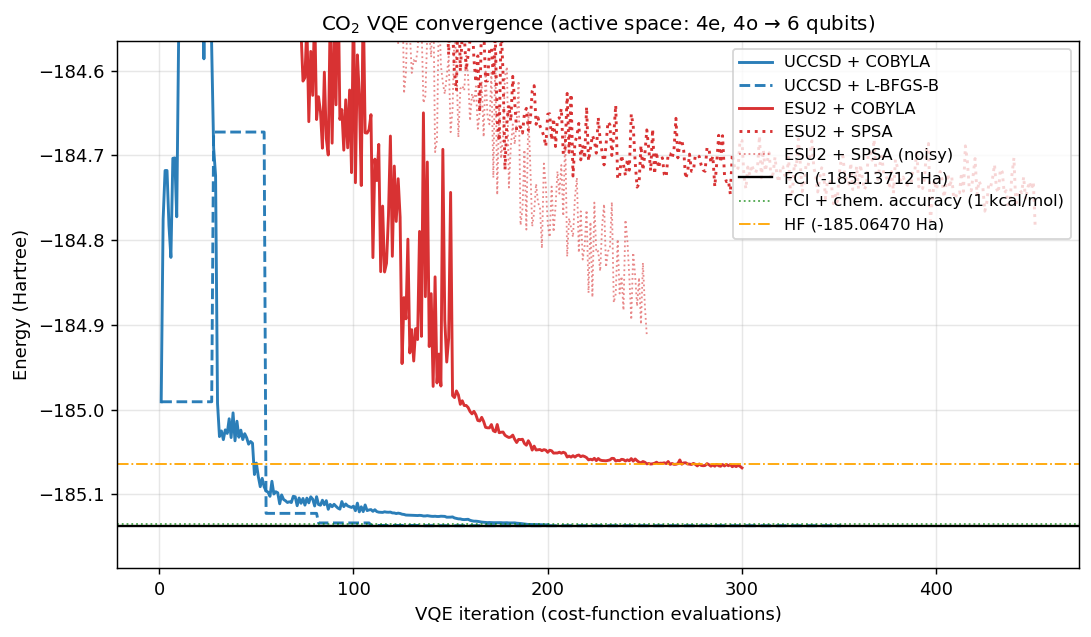

Saved fig1_convergence.png


In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))

for r in R["vqe"]:
    conv = np.asarray(r["convergence"], dtype=float)
    if conv.size == 0:
        continue
    ax.plot(
        np.arange(1, conv.size + 1), conv,
        color=COLORS.get(r["ansatz"], "gray"),
        linestyle=STYLES.get(r["optimizer"], "-"),
        linewidth=1.6 if not r["noisy"] else 1.0,
        alpha=0.95 if not r["noisy"] else 0.55,
        label=r["label"],
    )

ax.axhline(FCI, color="black",  ls="-",  lw=1.3, label=f"FCI ({FCI:.5f} Ha)")
ax.axhline(FCI + CHEM_ACC, color="green", ls=":", lw=1.0, alpha=0.7,
           label="FCI + chem. accuracy (1 kcal/mol)")
ax.axhline(HF,  color="orange", ls="-.", lw=1.0, label=f"HF ({HF:.5f} Ha)")
ax.set_xlabel("VQE iteration (cost-function evaluations)")
ax.set_ylabel("Energy (Hartree)")
ax.set_title("CO$_2$ VQE convergence (active space: 4e, 4o → 6 qubits)")
ax.legend(loc="upper right", frameon=True)
ax.grid(alpha=0.3)
ax.set_ylim(FCI - 0.05, HF + 0.5)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig1_convergence.png", dpi=150)
plt.show()
print("Saved fig1_convergence.png")

## 14. Figure 2 — Final Accuracy Bars

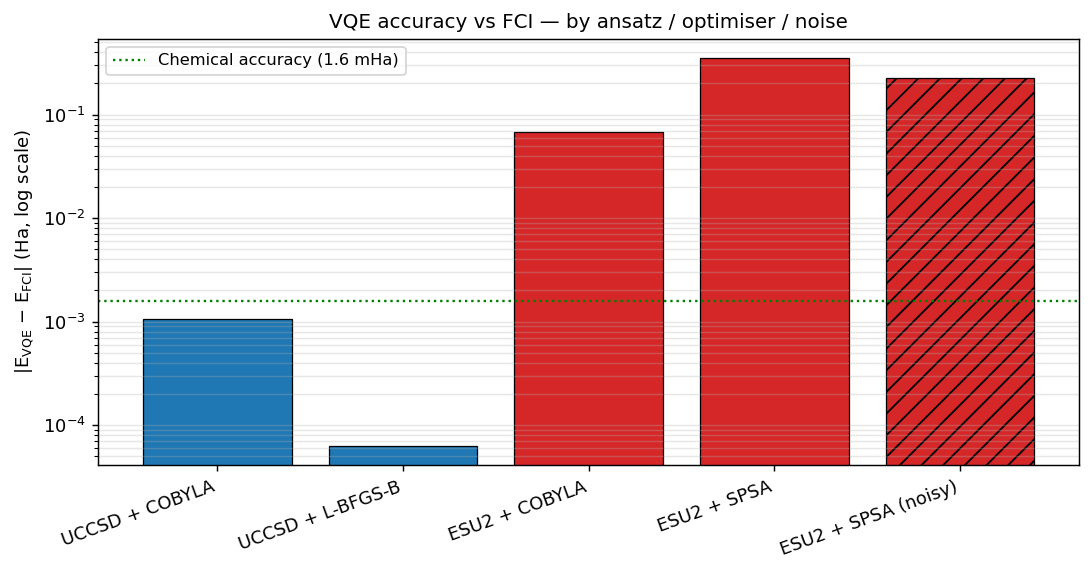

Saved fig2_accuracy_bars.png


In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))

labels  = [r["label"]        for r in R["vqe"]]
errors  = [r["error_vs_fci"] for r in R["vqe"]]
colors  = [COLORS.get(r["ansatz"], "gray") for r in R["vqe"]]
hatches = ["//" if r["noisy"] else "" for r in R["vqe"]]

bars = ax.bar(range(len(labels)), errors, color=colors, edgecolor="black", linewidth=0.7)
for b, h in zip(bars, hatches):
    b.set_hatch(h)

ax.set_yscale("log")
ax.axhline(CHEM_ACC, color="green", ls=":", lw=1.3, label="Chemical accuracy (1.6 mHa)")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("|E$_{\\mathrm{VQE}}$ − E$_{\\mathrm{FCI}}$| (Ha, log scale)")
ax.set_title("VQE accuracy vs FCI — by ansatz / optimiser / noise")
ax.grid(axis="y", alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "fig2_accuracy_bars.png", dpi=150)
plt.show()
print("Saved fig2_accuracy_bars.png")

## 15. Figure 3 — SQD Shot Scaling

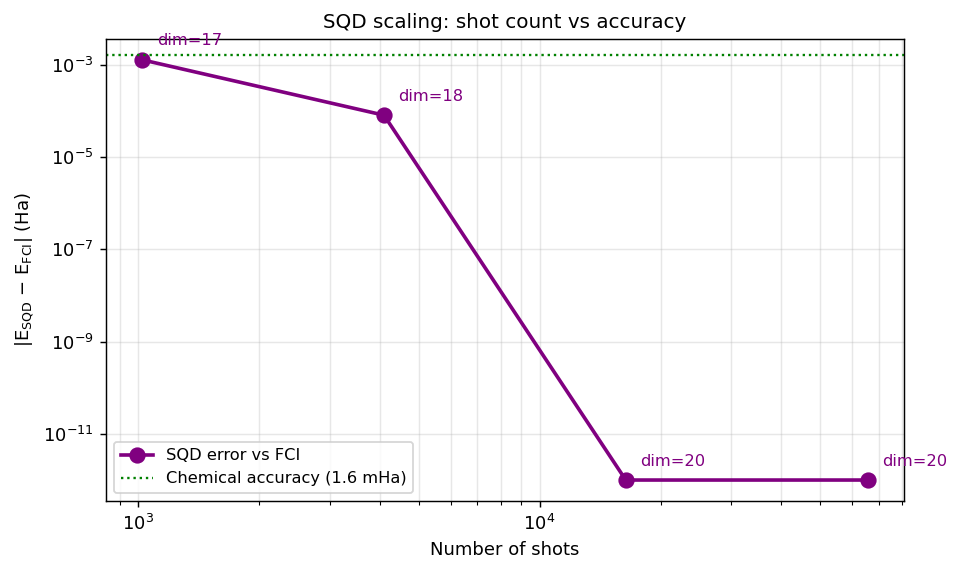

Saved fig3_sqd_scaling.png


In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))

shots = np.array([s["shots"]                        for s in R["sqd"]])
errs  = np.array([max(s["error_vs_fci"], 1e-12)     for s in R["sqd"]])
dims  = np.array([s["subspace_dim"]                  for s in R["sqd"]])

ax.loglog(shots, errs, "o-", color="purple", lw=2, ms=8, label="SQD error vs FCI")
ax.axhline(CHEM_ACC, color="green", ls=":", lw=1.3, label="Chemical accuracy (1.6 mHa)")
for x, y, d in zip(shots, errs, dims):
    ax.annotate(f"dim={d}", (x, y), textcoords="offset points",
                xytext=(8, 8), fontsize=9, color="purple")
ax.set_xlabel("Number of shots")
ax.set_ylabel("|E$_{\\mathrm{SQD}}$ − E$_{\\mathrm{FCI}}$| (Ha)")
ax.set_title("SQD scaling: shot count vs accuracy")
ax.grid(alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "fig3_sqd_scaling.png", dpi=150)
plt.show()
print("Saved fig3_sqd_scaling.png")

## 16. Figure 4 — Master Summary (All Methods vs FCI)

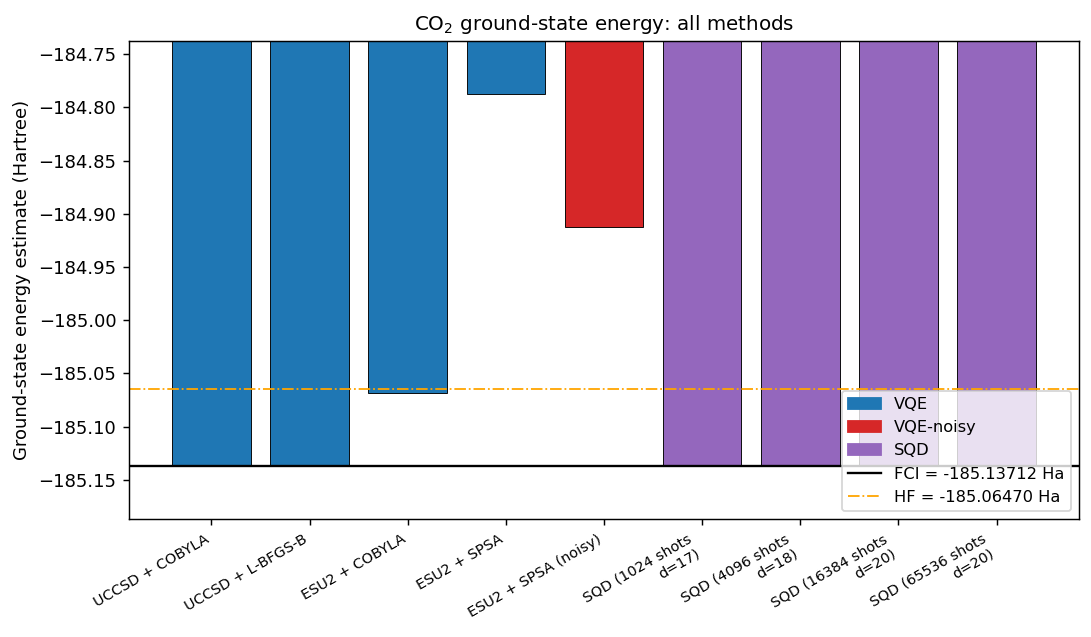

Saved fig4_summary.png

✅ Notebook complete. All figures written to /content/results


In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))

methods, energies, group = [], [], []
for r in R["vqe"]:
    methods.append(r["label"])
    energies.append(r["final_energy"])
    group.append("VQE-noisy" if r["noisy"] else "VQE")
for s in R["sqd"]:
    methods.append(s["label"].replace(", dim=", "\nd="))
    energies.append(s["energy"])
    group.append("SQD")

group_colors = {"VQE": "#1f77b4", "VQE-noisy": "#d62728", "SQD": "#9467bd"}
x = np.arange(len(methods))
ax.bar(x, energies, color=[group_colors[g] for g in group], edgecolor="black", lw=0.5)
ax.axhline(FCI, color="black",  ls="-",  lw=1.3, label=f"FCI = {FCI:.5f} Ha")
ax.axhline(HF,  color="orange", ls="-.", lw=1.0, label=f"HF = {HF:.5f} Ha")
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Ground-state energy estimate (Hartree)")
ax.set_title("CO$_2$ ground-state energy: all methods")
handles = [mpatches.Patch(color=v, label=k) for k, v in group_colors.items()]
ax.legend(handles=handles + ax.get_legend_handles_labels()[0], loc="lower right")
ax.set_ylim(min(energies + [FCI]) - 0.05, max(energies + [HF]) + 0.05)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig4_summary.png", dpi=150)
plt.show()
print("Saved fig4_summary.png")
print("\n✅ Notebook complete. All figures written to", OUT_DIR.resolve())